# Neural Network Architecture Visualization

This notebook creates visual representations and diagrams of the SimpleCNN and ResNet network architectures used in the face recognition project.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import sys
sys.path.append('.')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Define Network Models

We'll define the SimpleCNN model here for visualization.

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2, bn=False, init_bias=None):
        super(SimpleCNN, self).__init__()
        self.use_bn = bn
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=not bn)
        self.bn1 = nn.BatchNorm2d(32) if bn else nn.Identity()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=not bn)
        self.bn2 = nn.BatchNorm2d(64) if bn else nn.Identity()
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
simple_cnn = SimpleCNN(num_classes=2, bn=False, init_bias=1.0)
print("SimpleCNN model created successfully!")

SimpleCNN model created successfully!


## Section 2: Display Model Architecture Summary

Print the model structure and layer information.

In [3]:
print("SimpleCNN Architecture:")
print("=" * 80)
print(simple_cnn)
print("=" * 80)

# Count parameters
total_params = sum(p.numel() for p in simple_cnn.parameters())
trainable_params = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

SimpleCNN Architecture:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): Identity()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): Identity()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

Total Parameters: 1,198,850
Trainable Parameters: 1,198,850


## Section 4: Data Flow Through Network with Tensor Shapes

Trace the actual tensor shapes as data flows through the network.

In [5]:
# Create a sample input and trace tensor shapes
sample_input = torch.randn(1, 1, 48, 48)  # Batch size 1, 1 channel (grayscale), 48x48 image
print("Data Flow Through SimpleCNN:")
print("=" * 60)
print(f"Input tensor shape: {sample_input.shape}")

# Forward pass through each layer manually to show shapes
x = sample_input
print(f"After conv1:           {simple_cnn.conv1(x).shape}")
x = simple_cnn.conv1(x)
x = simple_cnn.bn1(x)
x = F.relu(x)
print(f"After ReLU + BN:       {x.shape}")

x = simple_cnn.pool(x)
print(f"After MaxPool:         {x.shape}")

x = simple_cnn.conv2(x)
x = simple_cnn.bn2(x)
x = F.relu(x)
print(f"After conv2 + ReLU:    {x.shape}")

x = simple_cnn.pool(x)
print(f"After MaxPool:         {x.shape}")

x = x.view(x.size(0), -1)
print(f"After Flatten:         {x.shape}")

x = F.relu(simple_cnn.fc1(x))
print(f"After fc1 + ReLU:      {x.shape}")

x = simple_cnn.fc2(x)
print(f"After fc2 (output):    {x.shape}")
print("=" * 60)

Data Flow Through SimpleCNN:
Input tensor shape: torch.Size([1, 1, 48, 48])
After conv1:           torch.Size([1, 32, 48, 48])
After ReLU + BN:       torch.Size([1, 32, 48, 48])
After MaxPool:         torch.Size([1, 32, 24, 24])
After conv2 + ReLU:    torch.Size([1, 64, 24, 24])
After MaxPool:         torch.Size([1, 64, 12, 12])
After Flatten:         torch.Size([1, 9216])
After fc1 + ReLU:      torch.Size([1, 128])
After fc2 (output):    torch.Size([1, 2])


## Section 5: Detailed Layer Information and Parameter Breakdown

Display detailed information about each layer including parameters, computational complexity, and dimensions.

In [6]:
def get_layer_details(model):
    """Extract detailed information about each layer."""
    layers_info = []
    
    for name, module in model.named_modules():
        if name == '':  # Skip the top-level model
            continue
        
        params = sum(p.numel() for p in module.parameters())
        
        if isinstance(module, nn.Conv2d):
            info = {
                'name': name,
                'type': 'Conv2d',
                'in_channels': module.in_channels,
                'out_channels': module.out_channels,
                'kernel_size': module.kernel_size,
                'padding': module.padding,
                'stride': module.stride,
                'parameters': params
            }
        elif isinstance(module, nn.Linear):
            info = {
                'name': name,
                'type': 'Linear',
                'in_features': module.in_features,
                'out_features': module.out_features,
                'parameters': params
            }
        elif isinstance(module, nn.BatchNorm2d):
            info = {
                'name': name,
                'type': 'BatchNorm2d',
                'num_features': module.num_features,
                'parameters': params
            }
        elif isinstance(module, nn.MaxPool2d):
            info = {
                'name': name,
                'type': 'MaxPool2d',
                'kernel_size': module.kernel_size,
                'stride': module.stride,
                'parameters': 0
            }
        else:
            continue
        
        layers_info.append(info)
    
    return layers_info

# Get layer information
layer_details = get_layer_details(simple_cnn)

# Display as formatted table
print("\nDetailed Layer Information:")
print("=" * 100)
print(f"{'Layer Name':<20} {'Type':<15} {'Configuration':<50} {'Parameters':<15}")
print("-" * 100)

for layer in layer_details:
    name = layer['name']
    layer_type = layer['type']
    params = layer['parameters']
    
    if layer_type == 'Conv2d':
        config = f"In: {layer['in_channels']}, Out: {layer['out_channels']}, Kernel: {layer['kernel_size']}"
    elif layer_type == 'Linear':
        config = f"In: {layer['in_features']}, Out: {layer['out_features']}"
    elif layer_type == 'BatchNorm2d':
        config = f"Features: {layer['num_features']}"
    elif layer_type == 'MaxPool2d':
        config = f"Kernel: {layer['kernel_size']}, Stride: {layer['stride']}"
    else:
        config = ""
    
    print(f"{name:<20} {layer_type:<15} {config:<50} {params:<15,}")

print("=" * 100)
print(f"Total Parameters: {total_params:,}")


Detailed Layer Information:
Layer Name           Type            Configuration                                      Parameters     
----------------------------------------------------------------------------------------------------
conv1                Conv2d          In: 1, Out: 32, Kernel: (3, 3)                     320            
conv2                Conv2d          In: 32, Out: 64, Kernel: (3, 3)                    18,496         
pool                 MaxPool2d       Kernel: 2, Stride: 2                               0              
fc1                  Linear          In: 9216, Out: 128                                 1,179,776      
fc2                  Linear          In: 128, Out: 2                                    258            
Total Parameters: 1,198,850


## Section 6: Create a Parameter Distribution Visualization

Visualize how parameters are distributed across different layers.

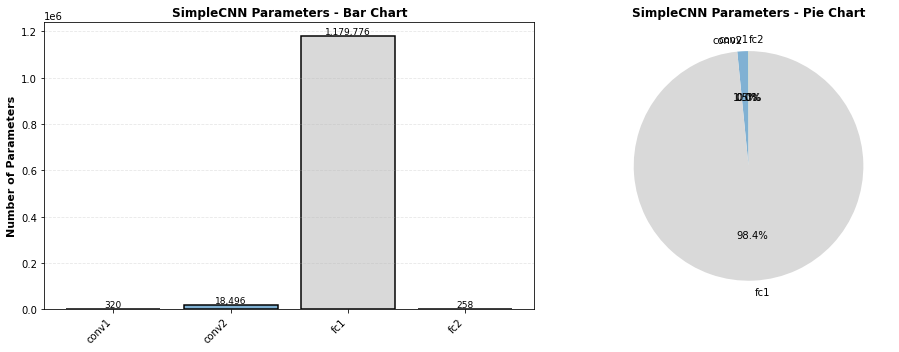

In [7]:
def visualize_parameter_distribution(model, title='Parameter Distribution'):
    """Create a bar chart showing parameter distribution across layers."""
    layer_details = get_layer_details(model)
    
    # Filter out layers with 0 parameters
    layer_details = [l for l in layer_details if l['parameters'] > 0]
    
    names = [l['name'].split('.')[-1] for l in layer_details]
    params = [l['parameters'] for l in layer_details]
    colors = plt.cm.Set3(np.linspace(0, 1, len(names)))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    bars = ax1.bar(range(len(names)), params, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(names, rotation=45, ha='right')
    ax1.set_ylabel('Number of Parameters', fontsize=11, fontweight='bold')
    ax1.set_title(f'{title} - Bar Chart', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9)
    
    # Pie chart
    ax2.pie(params, labels=names, autopct='%1.1f%%', colors=colors, 
            startangle=90, textprops={'fontsize': 10})
    ax2.set_title(f'{title} - Pie Chart', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    return fig

fig2 = visualize_parameter_distribution(simple_cnn, 'SimpleCNN Parameters')
plt.show()

## Section 7: Advanced Architecture Diagram with Spatial Dimensions

A more sophisticated visualization showing spatial dimension changes through convolutional and pooling operations.

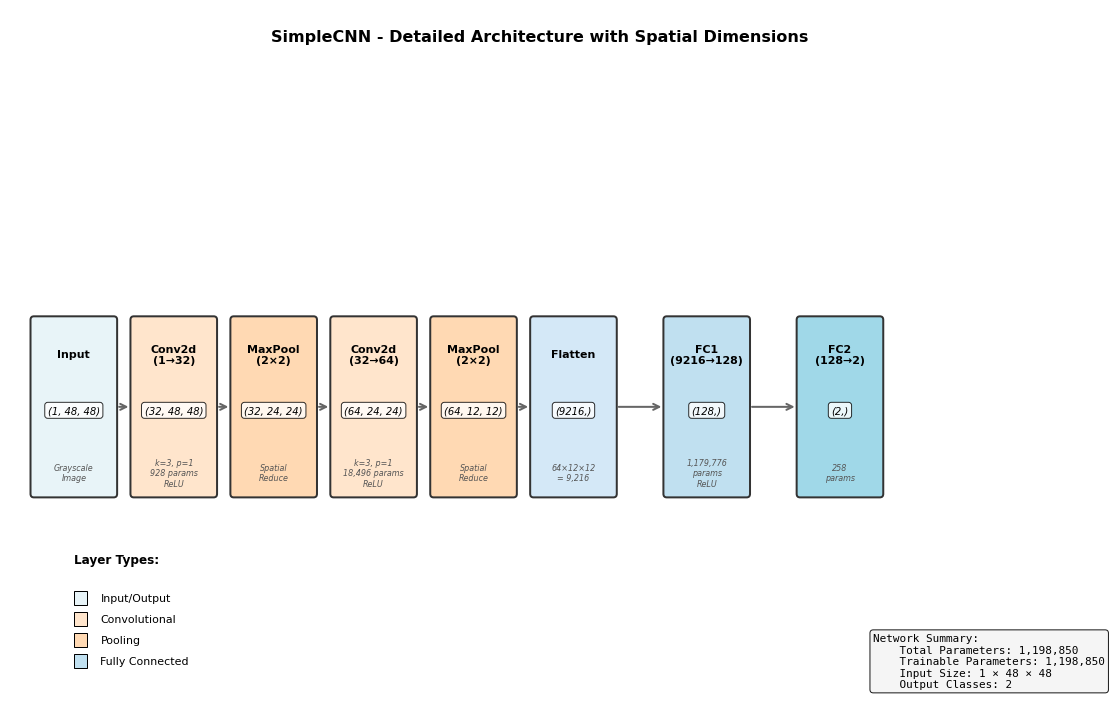

In [11]:
def visualize_detailed_architecture():
    """Create an advanced architecture diagram with spatial dimension visualization."""
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Title
    ax.text(8, 9.5, 'SimpleCNN - Detailed Architecture with Spatial Dimensions', 
            fontsize=16, fontweight='bold', ha='center')
    
    # Layer configurations
    layers = [
        # (x_pos, layer_info, color)
        (1, {'title': 'Input', 'shape': '(1, 48, 48)', 'details': 'Grayscale\nImage'}, '#E8F4F8'),
        (2.5, {'title': 'Conv2d\n(1→32)', 'shape': '(32, 48, 48)', 'details': 'k=3, p=1\n928 params\nReLU'}, '#FFE5CC'),
        (4, {'title': 'MaxPool\n(2×2)', 'shape': '(32, 24, 24)', 'details': 'Spatial\nReduce'}, '#FFD9B3'),
        (5.5, {'title': 'Conv2d\n(32→64)', 'shape': '(64, 24, 24)', 'details': 'k=3, p=1\n18,496 params\nReLU'}, '#FFE5CC'),
        (7, {'title': 'MaxPool\n(2×2)', 'shape': '(64, 12, 12)', 'details': 'Spatial\nReduce'}, '#FFD9B3'),
        (8.5, {'title': 'Flatten', 'shape': '(9216,)', 'details': '64×12×12\n= 9,216'}, '#D4E8F7'),
        (10.5, {'title': 'FC1\n(9216→128)', 'shape': '(128,)', 'details': '1,179,776\nparams\nReLU'}, '#C0E0F0'),
        (12.5, {'title': 'FC2\n(128→2)', 'shape': '(2,)', 'details': '258\nparams'}, '#A0D8E8'),
    ]
    
    for x_pos, layer_info, color in layers:
        # Main box
        box_width = 1.2
        box_height = 2.5
        box = FancyBboxPatch((x_pos - box_width/2, 3), box_width, box_height, 
                            boxstyle="round,pad=0.05", 
                            edgecolor='#333333', facecolor=color, linewidth=2)
        ax.add_patch(box)
        
        # Layer title
        ax.text(x_pos, 5, layer_info['title'], fontsize=11, fontweight='bold', 
               ha='center', va='center')
        
        # Output shape
        ax.text(x_pos, 4.2, layer_info['shape'], fontsize=10, ha='center', va='center',
               style='italic', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Details
        ax.text(x_pos, 3.3, layer_info['details'], fontsize=8, ha='center', va='center',
               style='italic', color='#555555')
        
        # Draw arrow
        if x_pos < 12.5:
            next_x = layers[layers.index((x_pos, layer_info, color)) + 1][0]
            arrow = FancyArrowPatch((x_pos + box_width/2 + 0.05, 4.25), 
                                  (next_x - box_width/2 - 0.05, 4.25),
                                  arrowstyle='->', mutation_scale=15, linewidth=2, color='#666666')
            ax.add_patch(arrow)
    
    # Add legend for layer types
    legend_y = 1.5
    legend_items = [
        ('Input/Output', '#E8F4F8'),
        ('Convolutional', '#FFE5CC'),
        ('Pooling', '#FFD9B3'),
        ('Fully Connected', '#C0E0F0'),
    ]
    
    ax.text(1, legend_y + 0.5, 'Layer Types:', fontsize=12, fontweight='bold')
    for i, (label, color) in enumerate(legend_items):
        y = legend_y - i*0.3
        rect = mpatches.Rectangle((1, y-0.1), 0.2, 0.2, facecolor=color, edgecolor='black', linewidth=1)
        ax.add_patch(rect)
        ax.text(1.4, y, label, fontsize=11, va='center')
    
    # Summary statistics
    summary_text = f"""Network Summary:
    Total Parameters: {total_params:,}
    Trainable Parameters: {trainable_params:,}
    Input Size: 1 × 48 × 48
    Output Classes: 2"""
    
    ax.text(13, legend_y - 0.5, summary_text, fontsize=11, 
           bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.9),
           verticalalignment='top', family='monospace')
    
    plt.tight_layout()
    return fig

fig3 = visualize_detailed_architecture()
plt.show()

## Section 8: Model Comparison - Different Configurations

Compare SimpleCNN with and without BatchNorm to visualize the impact of BN on the architecture.

In [9]:
# Create models with different configurations
simple_cnn_no_bn = SimpleCNN(num_classes=2, bn=False)
simple_cnn_with_bn = SimpleCNN(num_classes=2, bn=True)

# Compare statistics
print("Model Comparison: SimpleCNN with/without BatchNorm")
print("=" * 70)
print(f"{'Configuration':<30} {'Total Parameters':<20} {'Model Size (MB)':<20}")
print("-" * 70)

models_to_compare = [
    ("Without BatchNorm", simple_cnn_no_bn),
    ("With BatchNorm", simple_cnn_with_bn),
]

for config_name, model in models_to_compare:
    total_p = sum(p.numel() for p in model.parameters())
    # Approximate model size (4 bytes per float32 parameter)
    model_size_mb = (total_p * 4) / (1024 * 1024)
    print(f"{config_name:<30} {total_p:<20,} {model_size_mb:<20.4f}")

print("=" * 70)

Model Comparison: SimpleCNN with/without BatchNorm
Configuration                  Total Parameters     Model Size (MB)     
----------------------------------------------------------------------
Without BatchNorm              1,198,850            4.5732              
With BatchNorm                 1,198,946            4.5736              


## Section 9: Interactive Architecture Summary

Print a comprehensive summary of the network architecture suitable for documentation.

In [10]:
print("\n" + "="*80)
print("SIMPLECNN ARCHITECTURE SUMMARY")
print("="*80)

print("\n📋 NETWORK OVERVIEW:")
print("-" * 80)
print("Architecture Type:        Convolutional Neural Network (CNN)")
print("Input:                    Grayscale images (1 channel, 48×48 pixels)")
print("Output:                   Binary classification (2 classes: fear, angry)")
print("Task:                     Facial Expression Recognition")

print("\n🔧 LAYER BREAKDOWN:")
print("-" * 80)

layer_descriptions = [
    "1. Input Layer:              1 × 48 × 48 tensor (single grayscale image)",
    "2. Conv2d Layer 1:           1→32 filters, kernel 3×3, padding 1",
    "   - Output shape:           32 × 48 × 48",
    "   - Parameters:             928 (weights + biases)",
    "3. ReLU Activation:          Element-wise non-linearity",
    "4. MaxPooling 2×2:           Spatial downsampling",
    "   - Output shape:           32 × 24 × 24",
    "5. Conv2d Layer 2:           32→64 filters, kernel 3×3, padding 1",
    "   - Output shape:           64 × 24 × 24",
    "   - Parameters:             18,496",
    "6. ReLU Activation:          Element-wise non-linearity",
    "7. MaxPooling 2×2:           Spatial downsampling",
    "   - Output shape:           64 × 12 × 12",
    "8. Flatten Layer:            Convert spatial features to vector",
    "   - Output shape:           9,216 (64×12×12)",
    "9. Fully Connected Layer 1:  9,216 → 128 neurons",
    "   - Parameters:             1,179,776",
    "   - Activation:             ReLU",
    "10. Fully Connected Layer 2: 128 → 2 neurons (output)",
    "   - Parameters:             258",
    "   - Activation:             Softmax (implicit in loss function)",
]

for desc in layer_descriptions:
    print(desc)

print("\n📊 STATISTICS:")
print("-" * 80)
print(f"Total Parameters:         {total_params:,}")
print(f"Trainable Parameters:     {trainable_params:,}")
print(f"Model Size (FP32):        {(total_params * 4) / (1024 * 1024):.4f} MB")

print("\n🎯 KEY FEATURES:")
print("-" * 80)
print("• Two convolutional blocks for feature extraction")
print("• Spatial pooling to reduce dimensionality")
print("• Fully connected layers for classification")
print("• Customizable batch normalization")
print("• Customizable bias initialization")
print("• Supports variable initialization strategies")

print("\n" + "="*80)


SIMPLECNN ARCHITECTURE SUMMARY

📋 NETWORK OVERVIEW:
--------------------------------------------------------------------------------
Architecture Type:        Convolutional Neural Network (CNN)
Input:                    Grayscale images (1 channel, 48×48 pixels)
Output:                   Binary classification (2 classes: fear, angry)
Task:                     Facial Expression Recognition

🔧 LAYER BREAKDOWN:
--------------------------------------------------------------------------------
1. Input Layer:              1 × 48 × 48 tensor (single grayscale image)
2. Conv2d Layer 1:           1→32 filters, kernel 3×3, padding 1
   - Output shape:           32 × 48 × 48
   - Parameters:             928 (weights + biases)
3. ReLU Activation:          Element-wise non-linearity
4. MaxPooling 2×2:           Spatial downsampling
   - Output shape:           32 × 24 × 24
5. Conv2d Layer 2:           32→64 filters, kernel 3×3, padding 1
   - Output shape:           64 × 24 × 24
   - Parameters:  

## Section 10: ResNet Architecture Visualization

Now let's create similar visualizations for the ResNet18 model.


In [12]:
# Import ResNet from local file
from ResNet import ResNet

# Create ResNet18 model
resnet_model = ResNet(img_channels=1, num_layers=18, num_classes=2, bias=False, bn=True)

# Count parameters
resnet_total_params = sum(p.numel() for p in resnet_model.parameters())
resnet_trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print("ResNet18 Architecture:")
print("=" * 80)
print(f"Total Parameters: {resnet_total_params:,}")
print(f"Trainable Parameters: {resnet_trainable_params:,}")
print("=" * 80)


ResNet18 Architecture:
Total Parameters: 11,171,266
Trainable Parameters: 11,171,266


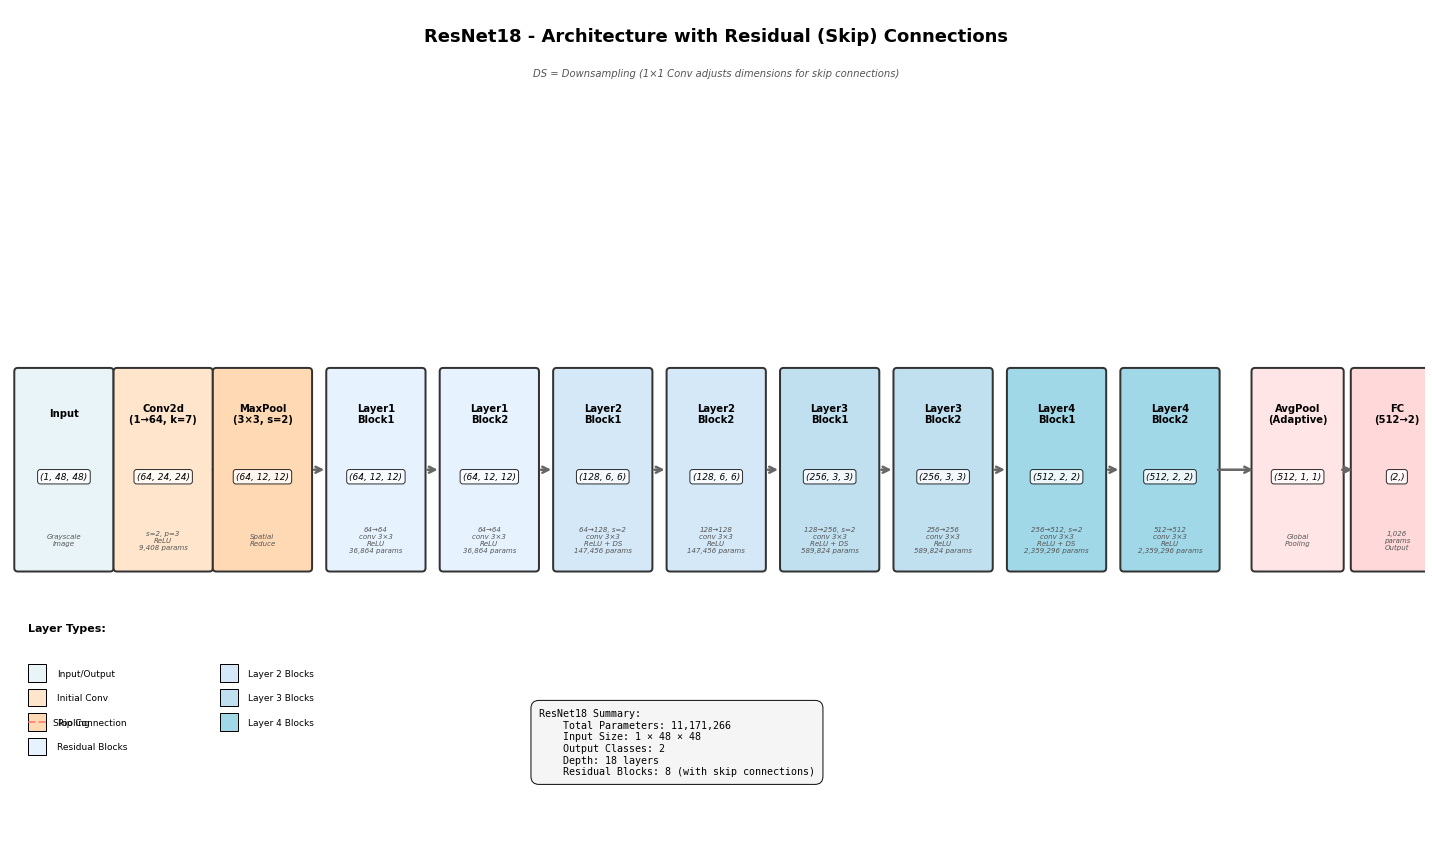

In [ ]:
def visualize_resnet_detailed_architecture():
    """Create a detailed architecture diagram for ResNet18 with spatial dimensions and skip connections."""
    fig, ax = plt.subplots(figsize=(20, 12))
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 12)
    ax.axis('off')
    
    # Title
    ax.text(10, 11.5, 'ResNet18 - Architecture with Residual (Skip) Connections', 
            fontsize=18, fontweight='bold', ha='center')
    
    # Subtitle explaining DS
    ax.text(10, 11, 'DS = Downsampling (1×1 Conv adjusts dimensions for skip connections)', 
            fontsize=10, ha='center', style='italic', color='#555555')
    
    # Layer configurations with more detail for ResNet blocks
    layers = [
        # Initial layers
        (0.8, {'title': 'Input', 'shape': '(1, 48, 48)', 'details': 'Grayscale\nImage'}, '#E8F4F8'),
        (2.2, {'title': 'Conv2d\n(1→64, k=7)', 'shape': '(64, 24, 24)', 'details': 's=2, p=3\nReLU\n9,408 params'}, '#FFE5CC'),
        (3.6, {'title': 'MaxPool\n(3×3, s=2)', 'shape': '(64, 12, 12)', 'details': 'Spatial\nReduce'}, '#FFD9B3'),
        
        # Layer 1: 2 blocks with 64 channels
        (5.2, {'title': 'Layer1\nBlock1', 'shape': '(64, 12, 12)', 'details': '64→64\nconv 3×3\nReLU\n36,864 params'}, '#E6F3FF'),
        (6.8, {'title': 'Layer1\nBlock2', 'shape': '(64, 12, 12)', 'details': '64→64\nconv 3×3\nReLU\n36,864 params'}, '#E6F3FF'),
        
        # Layer 2: 2 blocks with stride, 128 channels
        (8.4, {'title': 'Layer2\nBlock1', 'shape': '(128, 6, 6)', 'details': '64→128, s=2\nconv 3×3\nReLU + DS\n147,456 params'}, '#D4E8F7'),
        (10.0, {'title': 'Layer2\nBlock2', 'shape': '(128, 6, 6)', 'details': '128→128\nconv 3×3\nReLU\n147,456 params'}, '#D4E8F7'),
        
        # Layer 3: 2 blocks with stride, 256 channels
        (11.6, {'title': 'Layer3\nBlock1', 'shape': '(256, 3, 3)', 'details': '128→256, s=2\nconv 3×3\nReLU + DS\n589,824 params'}, '#C0E0F0'),
        (13.2, {'title': 'Layer3\nBlock2', 'shape': '(256, 3, 3)', 'details': '256→256\nconv 3×3\nReLU\n589,824 params'}, '#C0E0F0'),
        
        # Layer 4: 2 blocks with stride, 512 channels
        (14.8, {'title': 'Layer4\nBlock1', 'shape': '(512, 2, 2)', 'details': '256→512, s=2\nconv 3×3\nReLU + DS\n2,359,296 params'}, '#A0D8E8'),
        (16.4, {'title': 'Layer4\nBlock2', 'shape': '(512, 2, 2)', 'details': '512→512\nconv 3×3\nReLU\n2,359,296 params'}, '#A0D8E8'),
    ]
    
    for x_pos, layer_info, color in layers:
        # Main box
        box_width = 1.3
        box_height = 2.8
        box = FancyBboxPatch((x_pos - box_width/2, 4), box_width, box_height, 
                            boxstyle="round,pad=0.05", 
                            edgecolor='#333333', facecolor=color, linewidth=2)
        ax.add_patch(box)
        
        # Layer title
        ax.text(x_pos, 6.2, layer_info['title'], fontsize=10, fontweight='bold', 
               ha='center', va='center')
        
        # Output shape
        ax.text(x_pos, 5.3, layer_info['shape'], fontsize=9, ha='center', va='center',
               style='italic', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Details
        ax.text(x_pos, 4.4, layer_info['details'], fontsize=7, ha='center', va='center',
               style='italic', color='#555555')
        
        # Draw arrow
        if x_pos < 16.4:
            next_x = layers[layers.index((x_pos, layer_info, color)) + 1][0]
            arrow = FancyArrowPatch((x_pos + box_width/2 + 0.05, 5.4), 
                                  (next_x - box_width/2 - 0.05, 5.4),
                                  arrowstyle='->', mutation_scale=15, linewidth=2.5, color='#666666')
            ax.add_patch(arrow)
    
    # Draw skip connections (residual connections)
    skip_connections = [
        # (from_x, to_x, skip_type, offset_y)
        (5.2, 6.8, 'short', 0.2),      # Layer1: Block1 to Block2
        (8.4, 10.0, 'medium', 0.5),    # Layer2: Block1 to Block2
        (11.6, 13.2, 'medium', 0.5),   # Layer3: Block1 to Block2
        (14.8, 16.4, 'medium', 0.5),   # Layer4: Block1 to Block2
    ]
    
    for from_x, to_x, skip_type, offset_y in skip_connections:
        # Draw skip connection curve
        mid_x = (from_x + to_x) / 2
        curve_y = 7.0 + offset_y
        
    
    # Post-pooling and FC layers
    post_layers = [
        (18.2, {'title': 'AvgPool\n(Adaptive)', 'shape': '(512, 1, 1)', 'details': 'Global\nPooling'}, '#FFE5E5'),
        (19.6, {'title': 'FC\n(512→2)', 'shape': '(2,)', 'details': '1,026\nparams\nOutput'}, '#FFD9D9'),
    ]
    
    # Add final layers
    for x_pos, layer_info, color in post_layers:
        box_width = 1.2
        box_height = 2.8
        box = FancyBboxPatch((x_pos - box_width/2, 4), box_width, box_height, 
                            boxstyle="round,pad=0.05", 
                            edgecolor='#333333', facecolor=color, linewidth=2)
        ax.add_patch(box)
        
        ax.text(x_pos, 6.2, layer_info['title'], fontsize=10, fontweight='bold', 
               ha='center', va='center')
        ax.text(x_pos, 5.3, layer_info['shape'], fontsize=9, ha='center', va='center',
               style='italic', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        ax.text(x_pos, 4.4, layer_info['details'], fontsize=7, ha='center', va='center',
               style='italic', color='#555555')
    
    # Arrow to avg pool
    arrow = FancyArrowPatch((16.4 + 0.65, 5.4), (18.2 - 0.6, 5.4),
                          arrowstyle='->', mutation_scale=15, linewidth=2.5, color='#666666')
    ax.add_patch(arrow)
    
    # Arrow to FC
    arrow = FancyArrowPatch((18.2 + 0.6, 5.4), (19.6 - 0.6, 5.4),
                          arrowstyle='->', mutation_scale=15, linewidth=2.5, color='#666666')
    ax.add_patch(arrow)
    
    # Add legend for layer types
    legend_y = 2.5
    legend_items = [
        ('Input/Output', '#E8F4F8'),
        ('Initial Conv', '#FFE5CC'),
        ('Pooling', '#FFD9B3'),
        ('Residual Blocks', '#E6F3FF'),
        ('Layer 2 Blocks', '#D4E8F7'),
        ('Layer 3 Blocks', '#C0E0F0'),
        ('Layer 4 Blocks', '#A0D8E8'),
    ]
    
    ax.text(0.3, legend_y + 0.6, 'Layer Types:', fontsize=11, fontweight='bold')
    col_width = 2.7
    for i, (label, color) in enumerate(legend_items):
        col = i // 4
        row = i % 4
        x = 0.3 + col * col_width
        y = legend_y - row*0.35
        rect = mpatches.Rectangle((x, y-0.12), 0.25, 0.25, facecolor=color, edgecolor='black', linewidth=1)
        ax.add_patch(rect)
        ax.text(x + 0.4, y, label, fontsize=9, va='center')
    
    # Add skip connection indicator in legend
    ax.plot([0.3, 0.55], [1.8, 1.8], color='#FF6B6B', linewidth=2, linestyle='--', alpha=0.7)
    ax.text(0.65, 1.8, 'Skip Connection', fontsize=9, va='center')
    
    # Summary statistics
    summary_text = f"""ResNet18 Summary:
    Total Parameters: {resnet_total_params:,}
    Input Size: 1 × 48 × 48
    Output Classes: 2
    Depth: 18 layers
    Residual Blocks: 8 (with skip connections)"""
    
    ax.text(7.5, legend_y - 0.5, summary_text, fontsize=10, 
           bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.95, pad=0.8),
           verticalalignment='top', family='monospace')
    
    plt.tight_layout()
    return fig

fig4 = visualize_resnet_detailed_architecture()
plt.show()
